In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

In [161]:
def get_hand_line(p1, p2, segments=10, wobble=2, curvature=0):
    """Crea una linea con imperfezioni e una possibile curvatura (stile corsivo/tondeggiante)."""
    t = np.linspace(0, 1, segments)
    
    # Linea base tra p1 e p2
    x_vals = p1[0] + t * (p2[0] - p1[0])
    y_vals = p1[1] + t * (p2[1] - p1[1])
    
    # Aggiunta curvatura (arco quadratico)
    if curvature != 0:
        # Direzione perpendicolare alla linea per lo scostamento
        perp_x = -(p2[1] - p1[1])
        perp_y = (p2[0] - p1[0])
        dist = np.sqrt(perp_x**2 + perp_y**2) + 1e-6
        # Offset parabolico
        offset = 4 * curvature * t * (1 - t) 
        x_vals += (perp_x / dist) * offset
        y_vals += (perp_y / dist) * offset

    # Wobble (rumore casuale)
    x_vals += np.random.uniform(-wobble, wobble, segments)
    y_vals += np.random.uniform(-wobble, wobble, segments)
    
    # Assicura che l'inizio e la fine siano fissi
    x_vals[0], y_vals[0] = p1
    x_vals[-1], y_vals[-1] = p2
    return x_vals, y_vals

def draw_letter(ax, char, x, y, size, color, weight):
    """
    Disegna lettere con stili diversi: 
    'minimal' (rigido), 'italic' (inclinato), 'bubbly' (molto curvo).
    """
    # Seleziona uno stile casuale per questa lettera
    style = random.choice(['minimal', 'italic', 'bubbly'])
    
    # Parametri di stile
    slant = random.uniform(0.1, 0.4) if style == 'italic' else 0
    wobble_factor = 1.5 if style == 'bubbly' else 0.5
    curve_factor = random.uniform(2, 5) if style == 'bubbly' else 0
    
    s = size * 0.35 
    w = weight + random.uniform(-0.8, 0.8)
    paths = []

    # Funzione helper per applicare l'inclinazione (slant)
    def apply_style(pts):
        px, py = pts
        return px + (py - y) * slant, py

    if char == 'G':
        # Parametri per una G naturale
        # Se 'cleanliness' è alto, la lettera è più composta
        cleanliness = random.uniform(0.7, 0.95) 
        
        # 1. L'arco principale (un unico tratto fluido)
        # Partiamo dall'alto a destra (0.15 * pi) e giriamo fino a quasi chiudere
        t = np.linspace(0.15 * np.pi, 1.9 * np.pi, 40)
        
        # Variamo il raggio in modo asimmetrico per non farla sembrare un cerchio perfetto
        # ma senza farla sembrare storta
        rx = s * random.uniform(0.95, 1.05)
        ry = s * random.uniform(1.0, 1.1)
        
        arc_x = x + rx * np.cos(t)
        arc_y = y + ry * np.sin(t)
        
        # Applichiamo un po' di "tremolio" ma molto ridotto se vogliamo che sia dritta
        arc_x += np.random.normal(0, wobble_factor * (1 - cleanliness), len(t))
        arc_y += np.random.normal(0, wobble_factor * (1 - cleanliness), len(t))
        
        paths.append(apply_style((arc_x, arc_y)))
        
        # 2. La stangetta interna (tratto orizzontale)
        # Invece di farla partire dal centro perfetto, la facciamo partire
        # da dove finisce l'arco, andando verso l'interno.
        mid_x_end = x + s * 0.2
        mid_y = arc_y[-1]
        
        # Piccola correzione: se l'arco finisce troppo in basso, la alziamo
        if mid_y < y - s*0.2: mid_y = y - s*0.1 
            
        paths.append(apply_style(get_hand_line(
            (arc_x[-1], arc_y[-1]), 
            (mid_x_end, mid_y), 
            segments=5, 
            wobble=wobble_factor * 0.5
        )))

    elif char == 'T':
        y_top = y + s + random.uniform(-1, 1)
        # Barra orizzontale con curvatura casuale
        paths.append(apply_style(get_hand_line((x - s, y_top), (x + s, y_top), curvature=random.uniform(-1, 1))))
        # Asta verticale
        paths.append(apply_style(get_hand_line((x, y_top), (x, y - s), segments=8, wobble=wobble_factor)))

    elif char == 'B':
        v_x = x - s
        paths.append(apply_style(get_hand_line((v_x, y + s), (v_x, y - s), segments=10, wobble=wobble_factor)))
        # Due archi per la B
        for h_offset in [s/2, -s/2]:
            t = np.linspace(-np.pi/2, np.pi/2, 15)
            # Rende i "panzoni" della B irregolari
            curr_rx = s * random.uniform(0.7, 1.3)
            bx = v_x + curr_rx * np.cos(t)
            by = y + h_offset + (s/2) * np.sin(t)
            paths.append(apply_style((bx, by)))

    elif char == 'Y':
        joint_y = y + random.uniform(-s*0.2, s*0.2)
        # Braccia della Y possono essere curve (bubbly) o dritte
        paths.append(apply_style(get_hand_line((x - s, y + s), (x, joint_y), curvature=-curve_factor/2)))
        paths.append(apply_style(get_hand_line((x + s, y + s), (x, joint_y), curvature=curve_factor/2)))
        paths.append(apply_style(get_hand_line((x, joint_y), (x, y - s), segments=5, wobble=wobble_factor)))

    for px, py in paths:
        ax.plot(px, py, color=color, lw=w, solid_capstyle='round', alpha=0.85)

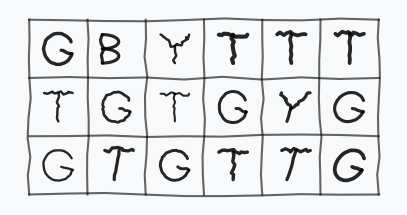

In [181]:
# 1. Parametri casuali per questa specifica esecuzione
rows, cols = random.randint(2, 6), random.randint(2, 6)
cell_size = 50
ink_color = random.choice(['#000000', '#1e1e1e', '#002b5b', '#4a0e0e'])
bg_color = random.choice(['#ffffff', '#fffaf0', '#f8f9fa'])

# 2. Setup del grafico
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor(bg_color)

# 3. Disegno della griglia "a mano"
w_grid = random.uniform(1.0, 2.5)
for i in range(rows + 1):
    ax.plot(*get_hand_line((0, i*cell_size), (cols*cell_size, i*cell_size), wobble=1.5), color=ink_color, lw=1.5, alpha=0.6)
for j in range(cols + 1):
    ax.plot(*get_hand_line((j*cell_size, 0), (j*cell_size, rows*cell_size), wobble=1.5), color=ink_color, lw=1.5, alpha=0.6)

# 4. Riempimento casuale
for r in range(rows):
    for c in range(cols):
        char = random.choice(['G', 'T', 'B', 'Y'])
        draw_letter(ax, char, c*cell_size + cell_size/2, r*cell_size + cell_size/2, cell_size*0.7, ink_color, 2.2)

plt.show()